# EECS 6320 — Q2 Deliverable  
## Preprocessing + Baseline Bias (21st Mortgage Corporation)

**Implementing Q2 milestone** for the final project:
- Preprocess the 21st Mortgage Corporation data
- Train a **baseline Random Forest** model for `action_taken`
- Measure **baseline bias** before any debiasing
- Prepare a clean foundation for **Q3 debiasing methods**

### Q2 Objective
The goal is to **preprocess the dataset and find the baseline bias**. The project also assigns this responsibility to the preprocessing / baseline-model track.

### Modeling Choice
To make Q2 precise and reproducible, this notebook converts `action_taken` into a **binary approval task**:
- `1` → **Approved / originated**
- `3` → **Denied**

All other action codes are excluded from the Q2 baseline so that the fairness analysis is focused on a clean approval-vs-denial decision.

### Sensitive Attributes Used
Primary:
- `applicant_sex`
- `applicant_race_1`

Secondary:
- `applicant_age`

### Fairness Metrics Reported
- **Demographic parity gap** 
- **Equal Opportunity Gap** (TPR gap)
- **False Positive Rate Gap**

---


In [2]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

from google.colab import drive
from pathlib import Path
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
from sklearn.neighbors import NearestNeighbors

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Set random seed
SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

In [3]:
# Mount Google Drive
drive.mount('/content/drive')

# Locate dataset automatically (works locally and in Colab)
candidate_paths = [
    Path("/mnt/data/21stMortgageCorporation_header.csv"),
    Path("./21stMortgageCorporation_header.csv"),
    Path("/content/21stMortgageCorporation_header.csv"),
    Path("/content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv"),
]

# Check all data paths to find applicable path to csv
DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = p
        break

# If no path is found, raise error
if DATA_PATH is None:
    raise FileNotFoundError("21stMortgageCorporation_header.csv not found. Upload it or update candidate_paths.")

# Set an output directory for results
OUT_DIR = Path("/mnt/data/eecs6320_q2_outputs") if Path("/mnt/data").exists() else Path("./eecs6320_q2_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Print input and output information
print(f"Using data file: {DATA_PATH}")
print(f"Saving outputs to: {OUT_DIR.resolve()}")

Mounted at /content/drive
Using data file: /content/drive/MyDrive/EECS6320/Dataset/21stMortgageCorporation_header.csv
Saving outputs to: /content/eecs6320_q2_outputs


## 1) Define Q2 columns and target setup

The project draft already identifies a baseline feature subset.  
For Q2 we keep those baseline features, evaluate fairness on sex/race/age, and use `action_taken` as the target.


In [4]:
# Define the target column
TARGET_COL = "action_taken"

# Define numeric columns
BASELINE_NUMERIC_COLS = [
    "loan_amount",
    "income",
    "property_value",
    "loan_term",
]

# Define categorical columns
BASELINE_CATEGORICAL_COLS = [
    "occupancy_type",
    "state_code",
    "county_code",
    "applicant_credit_scoring_model",
    "debt_to_income_ratio",
    "interest_only_payment",
]

# Define sensitive attribute columns
SENSITIVE_COLS = [
    "applicant_sex",
    "applicant_race_1",
    "applicant_age",
]

# Combine all columns
ALL_REQUIRED_COLS = BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS + [TARGET_COL]

# Print all columns
ALL_REQUIRED_COLS

['loan_amount',
 'income',
 'property_value',
 'loan_term',
 'occupancy_type',
 'state_code',
 'county_code',
 'applicant_credit_scoring_model',
 'debt_to_income_ratio',
 'interest_only_payment',
 'applicant_sex',
 'applicant_race_1',
 'applicant_age',
 'action_taken']

In [5]:
# Read only required columns.
# IMPORTANT: the uploaded 21st Mortgage Corporation file is pipe-delimited, not comma-delimited.
raw_df = pd.read_csv(DATA_PATH, sep="|", usecols=ALL_REQUIRED_COLS, dtype="string")

# Print dataframe statistics and header
print("Raw shape:", raw_df.shape)
raw_df.head()

Raw shape: (163986, 14)


,occupancy_type,loan_amount,action_taken,state_code,county_code,applicant_race_1,applicant_sex,applicant_age,income,applicant_credit_scoring_model,debt_to_income_ratio,loan_term,interest_only_payment,property_value
0,1,105000,3,LA,22031,5,1,25-34,<NA>,9,<NA>,276,2,<NA>
1,1,55000,6,SC,45035,7,4,8888,<NA>,9,<NA>,180,2,55000
2,1,55000,6,NC,37081,7,4,8888,<NA>,9,<NA>,180,2,55000
3,1,45000,6,NC,37183,7,4,8888,<NA>,9,<NA>,144,2,45000
4,1,35000,6,TX,48121,7,4,8888,<NA>,9,<NA>,120,2,35000


## 2) Clean the raw data

Cleaning steps:
1. Replace `?` and blank strings with missing values.
2. Trim whitespace.
3. Keep only the valid Q2 target classes (`1` = approved, `3` = denied).
4. Keep valid sensitive attribute categories:
   - sex: `1`, `2`
   - race: `2`, `3`, `5`  → Asian, Black, White
   - age: valid ordinal age buckets only
5. Convert numeric feature columns to numeric.
6. Create a binary target:
   - approved = 1
   - denied = 0


In [6]:
# Clean raw strings
df = raw_df.copy()
df = df.replace(["?", "<NA>", "NA", "N/A", "null", "None", ""], np.nan)
df = df.replace(r"^\s*$", np.nan, regex=True)

# For all columns, remove whitespace
for col in df.columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Keep valid target values for a clean approval-vs-denial baseline
df = df[df[TARGET_COL].isin(["1", "3"])].copy()

# Keep valid sensitive-attribute categories used in the current project design
valid_ages = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
df = df[df["applicant_sex"].isin(["1", "2"])].copy()
df = df[df["applicant_race_1"].isin(["2", "3", "5"])].copy()
df = df[df["applicant_age"].isin(valid_ages)].copy()

# Convert numeric baseline columns
for col in BASELINE_NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Binary target: 1=approved, 0=denied
df["target"] = df[TARGET_COL].map({"1": 1, "3": 0}).astype("int64")

# Cast categoricals explicitly
for col in BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS:
    df[col] = df[col].astype("object")

# Force any lingering pandas NA to np.nan
df = df.replace({pd.NA: np.nan})

# Print preprocessing results
print("Filtered / cleaned shape:", df.shape)
print("\nTarget distribution (1=approved, 0=denied):")
print(df["target"].value_counts(dropna=False))
print("\nMissing values after filtering:")
print(df[ALL_REQUIRED_COLS].isna().sum().sort_values(ascending=False))

Filtered / cleaned shape: (85241, 15)

Target distribution (1=approved, 0=denied):
target
0    62986
1    22255
Name: count, dtype: int64

Missing values after filtering:
property_value                    1731
income                            1730
debt_to_income_ratio              1723
loan_amount                          0
occupancy_type                       0
loan_term                            0
state_code                           0
county_code                          0
applicant_credit_scoring_model       0
interest_only_payment                0
applicant_sex                        0
applicant_race_1                     0
applicant_age                        0
action_taken                         0
dtype: int64


In [7]:
# Save cleaned Q2 dataset for reproducibility
clean_q2_path = OUT_DIR / "q2_cleaned_dataset.csv"
df.to_csv(clean_q2_path, index=False)
print(f"Saved cleaned dataset to: {clean_q2_path}")

Saved cleaned dataset to: eecs6320_q2_outputs/q2_cleaned_dataset.csv


## 3) Train/test split

Sensitive attributes are kept **for evaluation**.  
The baseline model itself uses only the baseline feature subset, so Q2 can evaluate fairness externally rather than baking protected attributes directly into the model.


In [8]:
# Define X, Y, and sensitive dataframe
X = df[BASELINE_NUMERIC_COLS + BASELINE_CATEGORICAL_COLS + SENSITIVE_COLS].copy()
y = df["target"].copy()

# Define the train/test split percentage
test_split = 0.25

# Create train and test splits for X, Y, and sensitive.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_split,
    random_state=SEED,
    stratify=y,
)

# Print train test split results
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True).rename("proportion"))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).rename("proportion"))

Train shape: (63930, 13)
Test shape: (21311, 13)

Train target distribution:
target
0    0.738918
1    0.261082
Name: proportion, dtype: float64

Test target distribution:
target
0    0.738914
1    0.261086
Name: proportion, dtype: float64


## 4) Preprocessing pipeline + baseline Random Forest

Why this pipeline is strong for Q2:
- numeric features are median-imputed,
- categorical features are mode-imputed and one-hot encoded,
- the train/test transformation is identical and reproducible,
- the model is a clean **baseline**, leaving debiasing work for Q3.


In [9]:
# Define a preprocessor transformer to impute numerical and categorical values
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
        ]), BASELINE_NUMERIC_COLS),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]), BASELINE_CATEGORICAL_COLS),
    ]
)

# Traing a Random Forest as the baseline model
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        )),
    ]
)

# Fit baseline to training data
baseline_model.fit(X_train, y_train)

# Find Y predictions and score
y_pred = baseline_model.predict(X_test)
y_score = baseline_model.predict_proba(X_test)[:, 1]

# Training successful
print("Baseline model trained successfully.")

Baseline model trained successfully.


### 4.1) MLP baseline


## 5) Baseline predictive performance

These metrics answer the question:  
**Is the baseline model functioning properly before we even talk about debiasing?**


In [10]:
# Calculate accuracy, balanced accuracy, area under curve, and confusion matrix
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_score)
cm = confusion_matrix(y_test, y_pred)

# Print all performance statistics
print(f"Accuracy:            {acc:.4f}")
print(f"Balanced Accuracy:   {bal_acc:.4f}")
print(f"ROC-AUC:             {auc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

Accuracy:            0.7966
Balanced Accuracy:   0.8260
ROC-AUC:             0.8893

Confusion Matrix:
[[12037  3710]
 [  625  4939]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9506    0.7644    0.8474     15747
           1     0.5710    0.8877    0.6950      5564

    accuracy                         0.7966     21311
   macro avg     0.7608    0.8260    0.7712     21311
weighted avg     0.8515    0.7966    0.8076     21311



## 6) Build fairness evaluation table

This evaluation frame keeps:
- sensitive attributes,
- true labels,
- predicted labels,
- predicted approval probability.


In [11]:
# Create a evaluation dataframe
eval_df = X_test[SENSITIVE_COLS].copy()
eval_df["y_true"] = y_test.to_numpy()
eval_df["y_pred"] = y_pred
eval_df["y_score"] = y_score

# Mapping for sex and race
sex_map = {"1": "Male", "2": "Female"}
race_map = {"2": "Asian", "3": "Black", "5": "White"}

# Add labels that map applicant sex and race
eval_df["sex_label"] = eval_df["applicant_sex"].map(sex_map)
eval_df["race_label"] = eval_df["applicant_race_1"].map(race_map)

# Display evaluation dataframe header
eval_df.head()

,applicant_sex,applicant_race_1,applicant_age,y_true,y_pred,y_score,sex_label,race_label
107761,1,5,25-34,0,0,0.325531,Male,White
68500,2,5,35-44,0,0,0.059441,Female,White
65752,2,3,35-44,0,0,0.062031,Female,Black
70072,1,5,25-34,0,0,0.239198,Male,White
113531,1,5,55-64,0,1,0.776289,Male,White


## 7) Fairness metrics

For each group we compute:
- **Base positive rate** = actual approval rate in the test set
- **Selection rate** = predicted approval rate
- **True positive rate** = equal opportunity measure
- **False positive rate**

Then we summarize:
- **Demographic parity gap** = max selection rate − min selection rate
- **Equal opportunity gap** = max TPR − min TPR
- **FPR gap** = max FPR − min FPR


In [12]:
# Define the fairness table
def fairness_table(input_df, group_col, positive_label=1):
    rows = []

    for group_value, gdf in input_df.groupby(group_col):
        # Not applicable group or empty gdf
        if pd.isna(group_value) or len(gdf) == 0:
            continue

        # Sum positive and negative labeling
        positive_true = (gdf["y_true"] == positive_label).sum()
        negative_true = (gdf["y_true"] != positive_label).sum()

        # Find selection rate and base positive rate
        selection_rate = float((gdf["y_pred"] == positive_label).mean())
        base_positive_rate = float((gdf["y_true"] == positive_label).mean())

        # Calculate TPR
        tpr = np.nan
        if positive_true > 0:
            tpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] == positive_label)).sum() / positive_true)

        # Calculate FPR
        fpr = np.nan
        if negative_true > 0:
            fpr = float(((gdf["y_pred"] == positive_label) & (gdf["y_true"] != positive_label)).sum() / negative_true)

        # Append to list of rows
        rows.append({
            "group": group_value,
            "n": int(len(gdf)),
            "base_positive_rate": base_positive_rate,
            "selection_rate": selection_rate,
            "true_positive_rate": tpr,
            "false_positive_rate": fpr,
        })

    # Create new dataframe for output
    out = pd.DataFrame(rows).sort_values("group").reset_index(drop=True)
    overall_selection_rate = float((input_df["y_pred"] == positive_label).mean())
    out["selection_rate_minus_overall"] = out["selection_rate"] - overall_selection_rate
    return out

# Fairness metric summary
def fairness_gap_summary(tbl):
    return pd.Series({
        "demographic_parity_gap": float(tbl["selection_rate"].max() - tbl["selection_rate"].min()),
        "equal_opportunity_gap": float(tbl["true_positive_rate"].max() - tbl["true_positive_rate"].min()),
        "false_positive_rate_gap": float(tbl["false_positive_rate"].max() - tbl["false_positive_rate"].min()),
    })

# Calculate rates per group
sex_fairness = fairness_table(eval_df, "sex_label")
race_fairness = fairness_table(eval_df, "race_label")
age_fairness = fairness_table(eval_df, "applicant_age")

# Calculate fairness metrics per group
sex_summary = fairness_gap_summary(sex_fairness)
race_summary = fairness_gap_summary(race_fairness)
age_summary = fairness_gap_summary(age_fairness)

# Print results for sex
print("Sex fairness table")
display(sex_fairness)
print("\nSex gap summary")
display(sex_summary.to_frame(name="value"))

# Print results for race
print("\nRace fairness table")
display(race_fairness)
print("\nRace gap summary")
display(race_summary.to_frame(name="value"))

# Print results for age
print("\nAge fairness table")
display(age_fairness)
print("\nAge gap summary")
display(age_summary.to_frame(name="value"))

Sex fairness table


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,Female,11246,0.217677,0.365463,0.880310,0.222210,-0.040383
1,Male,10065,0.309588,0.450969,0.893453,0.252554,0.045122



Sex gap summary


,value
demographic_parity_gap,0.085505
equal_opportunity_gap,0.013143
false_positive_rate_gap,0.030345



Race fairness table


...

,value
demographic_parity_gap,0.157776
equal_opportunity_gap,0.054381
false_positive_rate_gap,0.040870



Age fairness table


,group,n,base_positive_rate,selection_rate,true_positive_rate,false_positive_rate,selection_rate_minus_overall
0,25-34,6117,0.235736,0.397744,0.911234,0.239358,-0.008103
1,35-44,4984,0.235955,0.407103,0.906463,0.252889,0.001256
2,45-54,3678,0.277325,0.405111,0.893137,0.217833,-0.000735
3,55-64,2618,0.332697,0.449580,0.880597,0.234688,0.043733
4,65-74,1211,0.337737,0.398018,0.748166,0.219451,-0.007829
5,<25,2327,0.236356,0.389343,0.898182,0.231851,-0.016504
6,>74,376,0.255319,0.351064,0.843750,0.182143,-0.054783



Age gap summary


,value
demographic_parity_gap,0.098516
equal_opportunity_gap,0.163068
false_positive_rate_gap,0.070746


## 8) Visual summary

A quick visual summary for Q2:
- sex-based predicted approval rates,
- race-based predicted approval rates,
- age-based predicted approval rates.


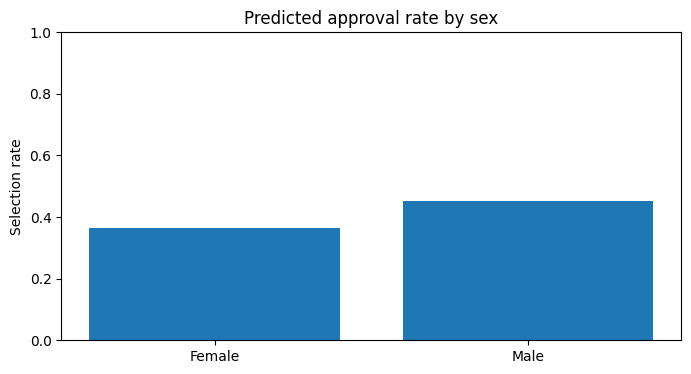

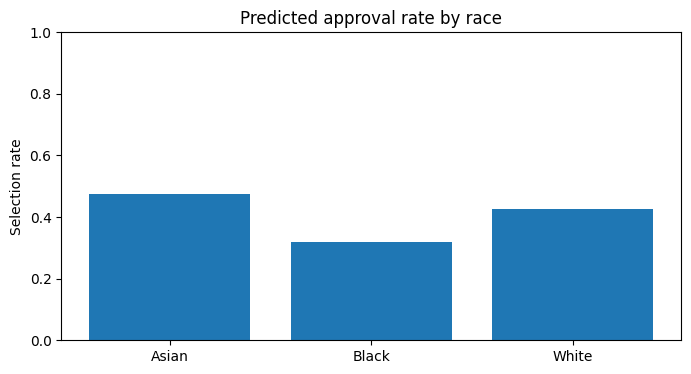

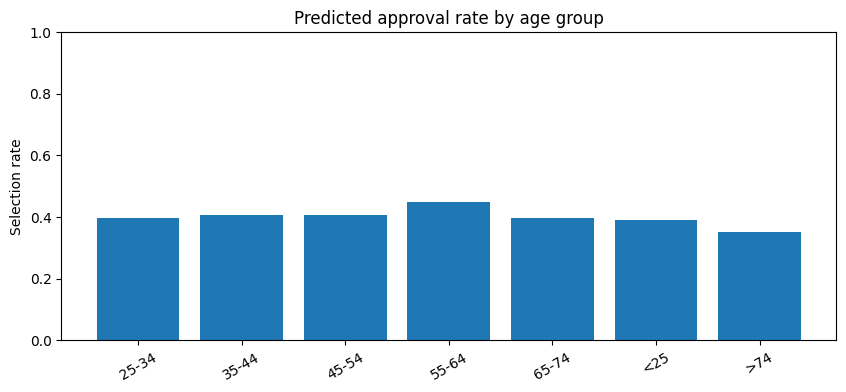

In [13]:
# Create graph for sex-based approval rates
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(sex_fairness["group"], sex_fairness["selection_rate"])
ax.set_title("Predicted approval rate by sex")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.show()

# Create graph for race-based approval rates
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(race_fairness["group"], race_fairness["selection_rate"])
ax.set_title("Predicted approval rate by race")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.show()

# Create graph for age-based approval rates
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(age_fairness["group"], age_fairness["selection_rate"])
ax.set_title("Predicted approval rate by age group")
ax.set_ylabel("Selection rate")
ax.set_ylim(0, 1)
plt.xticks(rotation=30)
plt.show()

## 9) Save Q2 result tables

Save the results for future reference.


In [14]:
# Output directory paths
sex_fairness_path = OUT_DIR / "q2_fairness_by_sex.csv"
race_fairness_path = OUT_DIR / "q2_fairness_by_race.csv"
age_fairness_path = OUT_DIR / "q2_fairness_by_age.csv"
metrics_path = OUT_DIR / "q2_model_metrics.csv"

# Convert dataframes to csv
sex_fairness.to_csv(sex_fairness_path, index=False)
race_fairness.to_csv(race_fairness_path, index=False)
age_fairness.to_csv(age_fairness_path, index=False)

# Summarize all baseline metrics into one baseline dataframe
metrics_df = pd.DataFrame([
    {"metric": "accuracy", "value": acc},
    {"metric": "balanced_accuracy", "value": bal_acc},
    {"metric": "roc_auc", "value": auc},
    {"metric": "sex_demographic_parity_gap", "value": float(sex_summary['demographic_parity_gap'])},
    {"metric": "sex_equal_opportunity_gap", "value": float(sex_summary['equal_opportunity_gap'])},
    {"metric": "race_demographic_parity_gap", "value": float(race_summary['demographic_parity_gap'])},
    {"metric": "race_equal_opportunity_gap", "value": float(race_summary['equal_opportunity_gap'])},
    {"metric": "age_demographic_parity_gap", "value": float(age_summary['demographic_parity_gap'])},
    {"metric": "age_equal_opportunity_gap", "value": float(age_summary['equal_opportunity_gap'])},
])

# Convert baseline dataframe to csv
metrics_df.to_csv(metrics_path, index=False)

# Print successfull save
print("Saved:")
print(" -", sex_fairness_path)
print(" -", race_fairness_path)
print(" -", age_fairness_path)
print(" -", metrics_path)

Saved:
 - eecs6320_q2_outputs/q2_fairness_by_sex.csv
 - eecs6320_q2_outputs/q2_fairness_by_race.csv
 - eecs6320_q2_outputs/q2_fairness_by_age.csv
 - eecs6320_q2_outputs/q2_model_metrics.csv


## 10) Q2 conclusion

We reached the **Q2 milestone**:

- The 21st Mortgage Corporation dataset was cleaned and filtered for a approval-vs-denial task,
- A baseline Random Forest model was trained,
- Predictive metrics were reported,
- Baseline fairness was measured across **sex**, **race**, and **age**,
- The outputs were saved so that **Q3 debiasing methods** can be compared directly against this baseline.

